# Notebook 02 — AnnData Construction and UMAP

Loading the full expression matrix, combining it with metadata and spatial 
coordinates, builing AnnData object, then normalization, and reproducing 
the UMAP from Mayassi et al. 2024.

**Input files:**
- `matrix.mtx` — 120,021 spots × 32,285 genes (sparse count matrix)
- `barcodes.tsv` — spot IDs
- `genes.tsv` — gene names
- `spatial_meta.tsv` — spot metadata
- `unroll_cluster.tsv` — spatial coordinates

**Output:**
- `data/processed/visium_gut.h5ad` — the complete AnnData object

## 1. Imports

In [24]:
import scipy.io
import pandas as pd
import numpy as np
import scanpy as sc
import os
import warnings
import matplotlib.pyplot as plt
import scipy.sparse as sp
import matplotlib.patches as mpatches
import psutil

## 2. Paths

In [2]:
VISIUM_DIR = "/home/wojmor/studies/MODEL/gut_project/data/raw/visium"
PROCESSED_DIR = "/home/wojmor/studies/MODEL/gut_project/data/processed"
FIGURES_DIR = "/home/wojmor/studies/MODEL/gut_project/results/figures"
sc.settings.figdir = FIGURES_DIR

### Other settings

In [3]:
sc.settings.verbosity = 3

## 3. Load the Count Matrix

The expression data is stored in Matrix Market format (`.mtx`), which is 
the standard sparse format used by 10x Genomics. Instead of storing all 
120,000 × 32,000 values (most of which are zero), it only stores the 
non-zero entries — this is what makes it manageable in memory.

We load three files together:
- `matrix.mtx` — the actual counts (which gene, which spot, how many reads)
- `barcodes.tsv` — the spot IDs (row labels)
- `genes.tsv` — the gene names (column labels)

In [4]:
print("Loading matrix...")

X = sp.csr_matrix(
    scipy.io.mmread(f"{VISIUM_DIR}/matrix.mtx"),
    dtype=np.float32
).T

barcodes = pd.read_csv(f"{VISIUM_DIR}/barcodes.tsv",
                        sep="\t", header=None)[0].values
genes = pd.read_csv(f"{VISIUM_DIR}/genes.tsv",
                    sep="\t", header=None)[0].values

print(f"Matrix shape (spots × genes): {X.shape}")
print(f"Barcodes: {len(barcodes)}")
print(f"Genes: {len(genes)}")

Loading matrix...
Matrix shape (spots × genes): (120021, 32285)
Barcodes: 120021
Genes: 32285


In [5]:
# Quick memory check after loading
mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB")
print(f"Memory available: {mem.available / 1e9:.1f} GB")

Memory used: 7.1 GB
Memory available: 18.1 GB


## 4. Build the AnnData Object

AnnData (Annotated Data) is the standard data structure used by Scanpy. 
Think of it as a smart container with several compartments:

- `adata.X` — the expression matrix (spots × genes)
- `adata.obs` — spot-level metadata (one row per spot: tissue region, microbe condition, etc.)
- `adata.var` — gene-level metadata (one row per gene: gene name, etc.)
- `adata.obsm` — additional coordinate matrices (UMAP, spatial coordinates)

We build it by combining the matrix with our metadata and spatial coordinates.

In [6]:
# Build the AnnData object
adata = sc.AnnData(X=X)
adata.obs_names = barcodes
adata.var_names = genes

print(f"AnnData created: {adata}")

AnnData created: AnnData object with n_obs × n_vars = 120021 × 32285


## 5. Attach Metadata to the AnnData Object

We load the spatial metadata and unrolled coordinates, then attach them 
to `adata.obs` (spot-level annotations) and `adata.obsm` (coordinate matrices).
We need to align all tables by their shared spot barcodes.

In [7]:
# Load and clean metadata
spatial_meta = pd.read_csv(f"{VISIUM_DIR}/spatial_meta.tsv", sep="\t", index_col=0)
spatial_meta = spatial_meta[spatial_meta.index != 'TYPE']

# Load and clean unrolled coordinates
unroll = pd.read_csv(f"{VISIUM_DIR}/unroll_cluster.tsv", sep="\t", 
                     index_col=0, low_memory=False)
unroll = unroll[unroll.index != 'TYPE']
unroll[['X', 'Y']] = unroll[['X', 'Y']].apply(pd.to_numeric, errors='coerce')

# Load and clean UMAP coordinates
spatial_umap = pd.read_csv(f"{VISIUM_DIR}/spatial_cluster.tsv", sep="\t", 
                            index_col=0, low_memory=False)
spatial_umap = spatial_umap[spatial_umap.index != 'TYPE']
spatial_umap[['X', 'Y']] = spatial_umap[['X', 'Y']].apply(pd.to_numeric, errors='coerce')

print(f"Metadata spots:   {spatial_meta.shape[0]}")
print(f"Unroll spots:     {unroll.shape[0]}")
print(f"UMAP spots:       {spatial_umap.shape[0]}")
print(f"AnnData spots:    {adata.n_obs}")

Metadata spots:   120021
Unroll spots:     119285
UMAP spots:       120021
AnnData spots:    120021


## 6. Align and Attach Metadata

In [8]:
# Attach core metadata columns to adata.obs
# We only keep spots present in both the matrix and the metadata
cols_to_keep = ['tissue_region', 'microbe', 'donor_id', 'biosample_id', 'sex', 'age']
spatial_meta_sub = spatial_meta[cols_to_keep]

adata.obs = adata.obs.join(spatial_meta_sub, how='left')

# Attach unrolled coordinates to adata.obsm
unroll_sub = unroll[['X', 'Y']].reindex(adata.obs_names)
adata.obsm['X_unroll'] = unroll_sub.values

# Attach UMAP coordinates to adata.obsm
umap_sub = spatial_umap[['X', 'Y']].reindex(adata.obs_names)
adata.obsm['X_umap_paper'] = umap_sub.values

# Attach ylayer (villus layer annotation) from unroll file
adata.obs['ylayer'] = unroll['ylayer'].reindex(adata.obs_names)
adata.obs['tissue'] = unroll['tissue'].reindex(adata.obs_names)

print(adata)
print(f"\nobs columns: {adata.obs.columns.tolist()}")
print(f"\nMissing tissue_region: {adata.obs['tissue_region'].isna().sum()}")
print(f"Missing ylayer: {adata.obs['ylayer'].isna().sum()}")

AnnData object with n_obs × n_vars = 120021 × 32285
    obs: 'tissue_region', 'microbe', 'donor_id', 'biosample_id', 'sex', 'age', 'ylayer', 'tissue'
    obsm: 'X_unroll', 'X_umap_paper'

obs columns: ['tissue_region', 'microbe', 'donor_id', 'biosample_id', 'sex', 'age', 'ylayer', 'tissue']

Missing tissue_region: 0
Missing ylayer: 736


## 7. QC
Spots with very low counts are likely empty or damaged tissue.
Spots with very high counts or very high mitochondrial gene expression 
can indicate technical artifacts.

In [9]:
# Calculate QC metrics
# Flag mitochondrial genes (start with "mt-" in mouse)
adata.var['mt'] = adata.var_names.str.startswith('mt-')

sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

print("QC metrics calculated.")
print(f"\nMedian counts per spot:       {adata.obs['total_counts'].median():.0f}")
print(f"Median genes per spot:        {adata.obs['n_genes_by_counts'].median():.0f}")
print(f"Median % mitochondrial:       {adata.obs['pct_counts_mt'].median():.1f}%")

QC metrics calculated.

Median counts per spot:       18059
Median genes per spot:        4203
Median % mitochondrial:       4.2%


## 8. QC metrics visualisation

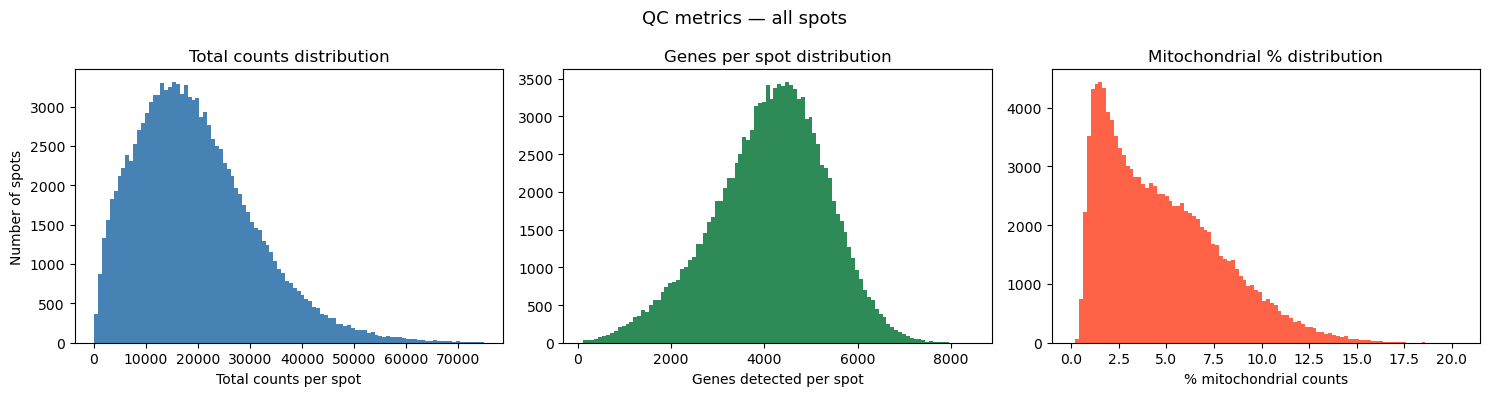

QC figure saved.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(adata.obs['total_counts'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Total counts per spot')
axes[0].set_ylabel('Number of spots')
axes[0].set_title('Total counts distribution')

axes[1].hist(adata.obs['n_genes_by_counts'], bins=100, color='seagreen', edgecolor='none')
axes[1].set_xlabel('Genes detected per spot')
axes[1].set_title('Genes per spot distribution')

axes[2].hist(adata.obs['pct_counts_mt'], bins=100, color='tomato', edgecolor='none')
axes[2].set_xlabel('% mitochondrial counts')
axes[2].set_title('Mitochondrial % distribution')

plt.suptitle('QC metrics — all spots', fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_qc_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("QC figure saved.")

## 9. Filtering
Based on the QC conservative filters were applied:
- Remove spots with fewer than 500 counts (likely empty spots at tissue edges)
- Remove spots with fewer than 200 genes detected
- Remove spots with more than 20% mitochondrial counts (damaged tissue)

In [11]:
print(f"Spots before filtering: {adata.n_obs}")

sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_cells(adata, min_genes=200)
adata = adata[adata.obs['pct_counts_mt'] < 20].copy()

print(f"Spots after filtering:  {adata.n_obs}")
print(f"Spots removed:          {120021 - adata.n_obs}")

Spots before filtering: 120021
filtered out 128 cells that have less than 500 counts
Spots after filtering:  119892
Spots removed:          129


## 10. Highly Variable Gene Selection

We don't need all 32,285 genes for dimensionality reduction. Most genes 
are either not expressed or expressed at the same level everywhere 
(housekeeping genes) and add noise rather than signal.

We select **highly variable genes (HVGs)** — genes whose expression varies 
substantially across spots. These are the genes that carry information 
about biological differences between tissue regions and cell types.

In [13]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor='seurat_v3',
    subset=False  
)

n_hvg = adata.var['highly_variable'].sum()
print(f"Highly variable genes selected: {n_hvg} out of {adata.n_vars}")

extracting highly variable genes


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
Highly variable genes selected: 3000 out of 32285


## 11. Normalization and Log Transformation

Raw counts are affected by technical variation — some spots capture more 
RNA simply because of how the tissue sits on the slide, not because of 
biology. Normalization corrects for this.

We use the standard approach:
1. **Normalize per spot** — scale each spot to 10,000 total counts 
   (library size normalization). This makes spots comparable regardless 
   of how much RNA was captured.
2. **Log1p transform** — apply log(x+1). This compresses the dynamic 
   range so that highly expressed genes don't dominate the analysis, 
   and makes the data more normally distributed for downstream statistics.

In [14]:
# Store raw counts before normalization
adata.raw = adata

# Normalize
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("Normalization complete.")
print(f"Example — first gene, first 5 spots (normalized): {adata.X[0:5, 0].toarray().flatten().round(3)}")

normalizing counts per cell
    finished (0:00:04)
Normalization complete.
Example — first gene, first 5 spots (normalized): [0. 0. 0. 0. 0.]


## 12. PCA
Dimentionality reduction

In [ ]:
# Memory check before PCA
mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB")
print(f"Memory available: {mem.available / 1e9:.1f} GB")

In [16]:
sc.tl.pca(adata, n_comps=50, use_highly_variable=True, zero_center=False)
print(f"PCA shape: {adata.obsm['X_pca'].shape}")

Before — used: 15.4 GB / available: 9.8 GB
computing PCA


/tmp/ipykernel_233720/1722351600.py:4: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, n_comps=50, use_highly_variable=True, zero_center=False)


    with n_comps=50
    finished (0:00:21)
After — used: 19.2 GB / available: 6.0 GB
PCA shape: (119892, 50)


## 13. Neighborhood graph

In [17]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
print("Neighborhood graph built.")

Before — used: 19.2 GB / available: 6.0 GB
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)
After — used: 15.9 GB / available: 9.3 GB
Neighborhood graph built.


## 14. UMAP
UMAP projects the neighborhood graph into 2D for visualization. 
Spots similar in gene expression end up close together.
Note: UMAP is for visualization only — all actual analysis 
is done in PCA space.

In [18]:
mem = psutil.virtual_memory()
print(f"Before — used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")

sc.tl.umap(adata)

mem = psutil.virtual_memory()
print(f"After — used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")
print(f"UMAP complete.")
print(f"UMAP shape: {adata.obsm['X_umap'].shape}")

Before — used: 15.9 GB / available: 9.3 GB
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:53)
After — used: 16.0 GB / available: 9.2 GB
UMAP complete.
UMAP shape: (119892, 2)


## 14. UMAP visualization

In [19]:
REGION_COLORS = {
    'Duodenum':  '#1f77b4',
    'Jejunum1':  '#ff7f0e',
    'Jejunum2':  '#2ca02c',
    'Ileum':     '#d62728',
    'Colon':     '#9467bd',
}

LAYER_COLORS = {
    'Top villous SI':    '#e41a1c',
    'Bottom villous SI': '#ff7f00',
    'Crypt SI':          '#4daf4a',
    'Muscle SI':         '#984ea3',
    'Crypt+LP colon':    '#377eb8',
    'Epi colon':         '#a65628',
    'Muscle colon':      '#999999',
}

MICROBE_COLORS = {
    'SPF': '#2166ac',
    'GF':  '#d6604d',
    'FMT': '#4dac26',
}

def make_legend(color_dict, ax, fontsize=9):
    patches = [mpatches.Patch(color=c, label=l)
               for l, c in color_dict.items()]
    ax.legend(handles=patches, fontsize=fontsize,
              markerscale=6, framealpha=0.8)

print("Color schemes defined.")

Color schemes defined.


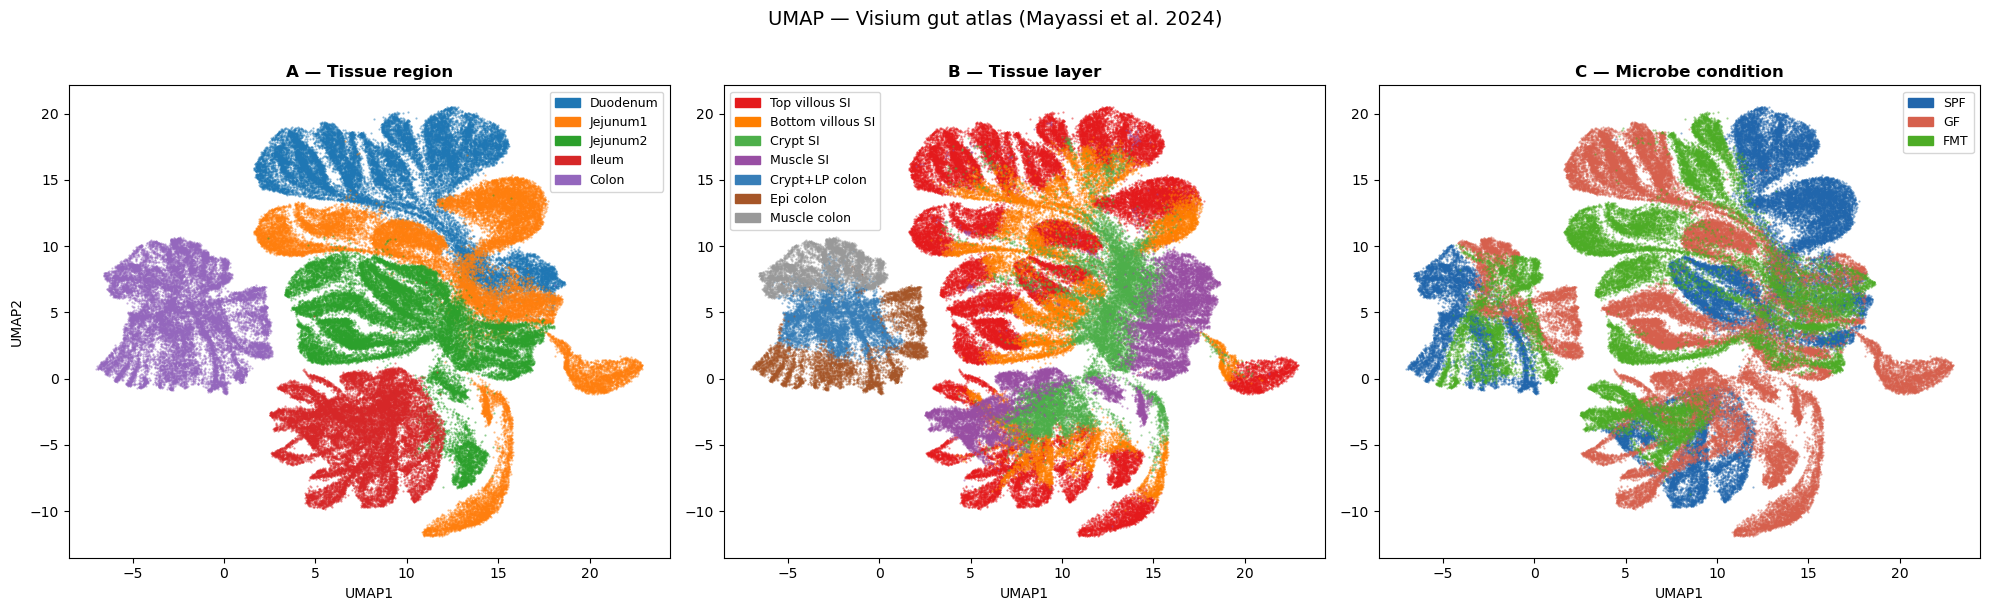

Figure 2 saved.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel A: by tissue region
ax = axes[0]
for region, color in REGION_COLORS.items():
    mask = adata.obs['tissue_region'] == region
    ax.scatter(adata.obsm['X_umap'][mask, 0],
               adata.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('A — Tissue region', fontweight='bold')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
make_legend(REGION_COLORS, ax)

# Panel B: by villus layer
ax = axes[1]
for layer, color in LAYER_COLORS.items():
    mask = adata.obs['ylayer'] == layer
    ax.scatter(adata.obsm['X_umap'][mask, 0],
               adata.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('B — Tissue layer', fontweight='bold')
ax.set_xlabel('UMAP1')
make_legend(LAYER_COLORS, ax)

# Panel C: by microbe condition
ax = axes[2]
for microbe, color in MICROBE_COLORS.items():
    mask = adata.obs['microbe'] == microbe
    ax.scatter(adata.obsm['X_umap'][mask, 0],
               adata.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('C — Microbe condition', fontweight='bold')
ax.set_xlabel('UMAP1')
make_legend(MICROBE_COLORS, ax)

plt.suptitle('UMAP — Visium gut atlas (Mayassi et al. 2024)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_umap_overview.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

## 15. Save processed AnnData

In [23]:
save_path = f"{PROCESSED_DIR}/visium_gut.h5ad"
adata.write_h5ad(save_path)
print(f"Saved to: {save_path}")

size_gb = os.path.getsize(save_path) / 1e9
print(f"File size: {size_gb:.2f} GB")

Saved to: /home/wojmor/studies/MODEL/gut_project/data/processed/visium_gut.h5ad
File size: 7.99 GB
